# Prediksi Jalur Pabean (Hijau / Merah) — Versi 2

Notebook ini adalah **pengembangan** dari model sebelumnya (`ml_inklaring.ipynb`).

**Apa yang berubah dari versi lama:**
1. Data diambil langsung dari file Excel `INKLARING_BB_BD_BP___SPAREPART.xlsx` (kolom `Keterangan Jalur`), bukan dari kolom `SPJM` di database — karena setelah dicek, `SPJM` ternyata **100% bocor** dengan target (SPJM diisi *setelah* kapal ditetapkan Jalur Merah, jadi itu konsekuensi bukan penyebab).
2. Semua kolom yang baru terisi **setelah** jalur ditentukan (mis. `Lama Bongkar`, `GUDANG TIMBUN`, `START/SELESAI BONGKAR`, `Tgl SPPB`, dll) di-exclude — kalau dipakai, itu *data leakage* (model "curang" pakai info masa depan).
3. Beberapa model dibandingkan secara adil: Decision Tree (model lama), Logistic Regression, Random Forest, Gradient Boosting, dan XGBoost.
4. Karena data cuma ~69 baris berlabel, evaluasi pakai **Stratified K-Fold Cross-Validation** dan **Leave-One-Out CV**, bukan satu kali train-test split — supaya angka akurasi tidak "kebetulan bagus/jelek" tergantung pembagian data.

**Kesimpulan singkat (detail di bawah):** dengan data sekecil ini, model yang lebih canggih (Gradient Boosting) memang unggul tipis dibanding Decision Tree lama, tapi selisihnya kecil dan variansnya besar — jadi realistiknya semua model masih "sedang-sedang saja" (balanced accuracy ~0.6-0.7). Ini murni keterbatasan jumlah data, bukan karena teknik modelnya kurang canggih.


## 1. Load Data

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('INKLARING BB BD BP & SPAREPART.xlsx', sheet_name='2026 - BBBDBP', header=0)

# Hanya baris yang sudah punya label Jalur (beberapa PIB masih dalam proses / belum ditetapkan)
df = df.dropna(subset=['Keterangan Jalur']).reset_index(drop=True)

print(f"Total data berlabel: {len(df)} baris")
print(df['Keterangan Jalur'].value_counts())

Total data berlabel: 69 baris
Keterangan Jalur
HIJAU    45
MERAH    24
Name: count, dtype: int64


## 2. Cek Data Leakage pada SPJM

Ini konfirmasi kenapa `SPJM` **tidak boleh** dipakai sebagai fitur (walau di notebook lama sudah tidak dipakai — ini sekadar pembuktian bahwa keputusan itu benar).

In [2]:
is_hijau_from_spjm = df['SPJM'].fillna('').astype(str).str.strip().isin(['', '0', '0.0'])
pred_dari_spjm = np.where(is_hijau_from_spjm, 'HIJAU', 'MERAH')
match_rate = (pred_dari_spjm == df['Keterangan Jalur'].values).mean()

print(f"Match rate SPJM vs Keterangan Jalur aktual: {match_rate*100:.1f}%")
print("-> SPJM praktis SAMA dengan label targetnya sendiri (diisi SETELAH jalur ditentukan).")
print("   Kolom ini dan kolom pasca-penetapan jalur lainnya TIDAK dipakai sebagai fitur.")

Match rate SPJM vs Keterangan Jalur aktual: 100.0%
-> SPJM praktis SAMA dengan label targetnya sendiri (diisi SETELAH jalur ditentukan).
   Kolom ini dan kolom pasca-penetapan jalur lainnya TIDAK dipakai sebagai fitur.


## 3. Eksplorasi & Seleksi Fitur

Kita uji signifikansi statistik tiap fitur kandidat terhadap target, dan cek cardinality-nya (jumlah kategori unik) — karena dengan hanya 69 baris, fitur kategorikal dengan puluhan kategori unik (mis. `Port of Load`, `PEMASOK`, `PENGIRIM`) berisiko overfit alih-alih memberi sinyal asli.

**Semua fitur di bawah ini tersedia SEBELUM jalur ditentukan** (saat PIB diajukan), jadi aman dari data leakage.

In [3]:
from scipy.stats import chi2_contingency, mannwhitneyu

y_temp = (df['Keterangan Jalur'] == 'MERAH').astype(int)

cat_candidates = ['KOMODITI', 'ASAL NEGARA', 'Port of Load', 'HS', 'Kurs', 'PEMASOK', 'PENGIRIM', 'AGENT', 'PPJK']
num_candidates = ['QUANTITY (MT)', 'Bea Masuk (Rp)', 'PPN', 'PPH', 'TOTAL', 'BM % ']

print("=== Fitur Kategorikal: Chi-square test + cardinality ===")
rows = []
for c in cat_candidates:
    tmp = df[[c]].astype(str)
    ct = pd.crosstab(tmp[c], y_temp)
    chi2, p, dof, _ = chi2_contingency(ct)
    n_unique = tmp[c].nunique()
    rows.append([c, n_unique, round(n_unique/len(df), 2), round(p, 4)])
print(pd.DataFrame(rows, columns=['Fitur', 'N Unik', 'Rasio Unik/Total', 'p-value']).to_string(index=False))

print("\n=== Fitur Numerik: Mann-Whitney U test ===")
rows = []
for c in num_candidates:
    hijau = df.loc[y_temp==0, c].dropna()
    merah = df.loc[y_temp==1, c].dropna()
    stat, p = mannwhitneyu(hijau, merah, alternative='two-sided')
    rows.append([c, round(p, 4)])
print(pd.DataFrame(rows, columns=['Fitur', 'p-value']).to_string(index=False))

=== Fitur Kategorikal: Chi-square test + cardinality ===
       Fitur  N Unik  Rasio Unik/Total  p-value
    KOMODITI       9              0.13   0.0023
 ASAL NEGARA      12              0.17   0.1188
Port of Load      40              0.58   0.0818
          HS       9              0.13   0.0017
        Kurs       6              0.09   0.1188
     PEMASOK      33              0.48   0.0461
    PENGIRIM      40              0.58   0.0945
       AGENT      13              0.19   0.1536
        PPJK      12              0.17   0.2128

=== Fitur Numerik: Mann-Whitney U test ===
         Fitur  p-value
 QUANTITY (MT)   0.0002
Bea Masuk (Rp)   0.3084
           PPN   0.4535
           PPH   0.3845
         TOTAL   0.3289
         BM %    0.3084


**Interpretasi:**
- `KOMODITI` dan `HS` sangat signifikan (p < 0.01) — tapi keduanya hampir 1:1 (redundan), jadi cukup pakai `KOMODITI`.
- `QUANTITY (MT)` sangat signifikan (p < 0.001) — kapal dengan quantity lebih besar cenderung Jalur Merah.
- `ASAL NEGARA`, `PPN`, `PPH`, `TOTAL`, `BM%` **tidak signifikan** secara statistik di data ini (p > 0.05), meski `ASAL NEGARA` tetap dipertahankan karena secara domain biasanya relevan untuk risk assessment bea cukai, dan `TOTAL` dipertahankan mewakili aspek nilai pajak.
- `Port of Load`, `PEMASOK`, `PENGIRIM` — cardinality terlalu tinggi (rasio unik/total > 0.4) untuk data sekecil ini → tidak dipakai (terbukti pada eksperimen menurunkan akurasi, lihat notebook eksperimen).

## 4. Persiapan Fitur Final

In [4]:
cat_features = ['KOMODITI', 'ASAL NEGARA']
num_features = ['QUANTITY (MT)', 'TOTAL']

X = df[cat_features + num_features].copy()
X['QUANTITY (MT)'] = X['QUANTITY (MT)'].fillna(X['QUANTITY (MT)'].median())
y = (df['Keterangan Jalur'] == 'MERAH').astype(int)  # 1 = Merah, 0 = Hijau

print(f"Jumlah data: {len(X)} | Fitur: {list(X.columns)}")
print(f"Distribusi target -> Hijau: {sum(y==0)}, Merah: {sum(y==1)}")
X.head()

Jumlah data: 69 | Fitur: ['KOMODITI', 'ASAL NEGARA', 'QUANTITY (MT)', 'TOTAL']
Distribusi target -> Hijau: 45, Merah: 24


,KOMODITI,ASAL NEGARA,QUANTITY (MT),TOTAL
0,MOP,RUSIA,27500.000,23822303175
1,SULPHUR,QATAR,9899.663,12203072520
2,SULPHUR,QATAR,25499.255,31432271197
3,MOP,RUSIA,25026.000,21720569148
4,MOP,RUSIA,27500.000,23855006575


## 5. Perbandingan Model dengan Cross-Validation

Karena data sangat kecil, kita TIDAK memakai satu kali train-test split (hasilnya bisa menyesatkan — "kebetulan" gampang/susah tergantung baris mana yang jadi test). Kita pakai:
- **Stratified 5-Fold CV**, diulang 10x dengan seed berbeda, supaya hasil stabil.
- **Leave-One-Out CV** sebagai pembanding paling ketat untuk dataset kecil.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate, LeaveOneOut
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

RANDOM_STATE = 42

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('num', StandardScaler(), num_features),
])

models = {
    'Decision Tree (model lama)': DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=3,
                                             class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.1,
                                                      random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.05,
                              scale_pos_weight=sum(y==0)/sum(y==1),
                              eval_metric='logloss', random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
}

scoring = ['accuracy', 'balanced_accuracy', 'f1_macro', 'roc_auc']
results_summary = []
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    acc, bal_acc, f1, auc = [], [], [], []
    for seed in range(10):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        res = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
        acc.append(res['test_accuracy'].mean())
        bal_acc.append(res['test_balanced_accuracy'].mean())
        f1.append(res['test_f1_macro'].mean())
        auc.append(res['test_roc_auc'].mean())
    results_summary.append({
        'Model': name,
        'Accuracy': f"{np.mean(acc):.3f} ± {np.std(acc):.3f}",
        'Balanced Acc': f"{np.mean(bal_acc):.3f} ± {np.std(bal_acc):.3f}",
        'F1 Macro': f"{np.mean(f1):.3f} ± {np.std(f1):.3f}",
        'ROC AUC': f"{np.mean(auc):.3f} ± {np.std(auc):.3f}",
    })

results_df = pd.DataFrame(results_summary)
print("=== Stratified 5-Fold CV (rata-rata 10x pengulangan) ===")
results_df

=== Stratified 5-Fold CV (rata-rata 10x pengulangan) ===


,Model,Accuracy,Balanced Acc,F1 Macro,ROC AUC
0,Decision Tree (model lama),0.735 ± 0.034,0.649 ± 0.025,0.641 ± 0.028,0.732 ± 0.024
1,Logistic Regression,0.655 ± 0.037,0.633 ± 0.044,0.615 ± 0.039,0.770 ± 0.025
2,Random Forest,0.664 ± 0.028,0.631 ± 0.033,0.612 ± 0.038,0.710 ± 0.032
3,Gradient Boosting,0.727 ± 0.025,0.696 ± 0.031,0.689 ± 0.033,0.763 ± 0.030
4,XGBoost,0.657 ± 0.032,0.620 ± 0.033,0.604 ± 0.032,0.726 ± 0.039
5,SVM (RBF),0.686 ± 0.041,0.657 ± 0.042,0.637 ± 0.048,0.694 ± 0.061


In [6]:
# Leave-One-Out CV — paling robust untuk dataset sekecil ini
loo = LeaveOneOut()
loo_results = []
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    res = cross_validate(pipe, X, y, cv=loo, scoring=['accuracy'])
    loo_results.append({'Model': name, 'LOO Accuracy': f"{res['test_accuracy'].mean():.3f}"})

print("=== Leave-One-Out CV ===")
pd.DataFrame(loo_results)

=== Leave-One-Out CV ===


,Model,LOO Accuracy
0,Decision Tree (model lama),0.754
1,Logistic Regression,0.681
2,Random Forest,0.667
3,Gradient Boosting,0.768
4,XGBoost,0.681
5,SVM (RBF),0.754


**Catatan penting:** perbedaan skor antar model relatif kecil dan berada dalam rentang standar deviasinya masing-masing (lihat kolom "±"). Ini artinya dengan data sebanyak ini, kita **belum bisa menyimpulkan dengan yakin** model mana yang "benar-benar" lebih unggul secara statistik — semua model berada di kisaran performa yang mirip. Balanced Accuracy ~0.6–0.7 mengindikasikan model jauh lebih baik dari tebakan acak (0.5), tapi juga belum sangat akurat.

## 6. Hyperparameter Tuning + Nested Cross-Validation

Untuk memastikan hasil di atas bukan karena parameter default yang kurang optimal, kita lakukan tuning dengan **nested CV**: GridSearch mencari parameter terbaik di dalam setiap fold (inner loop), lalu dievaluasi di data yang belum pernah dilihat GridSearch (outer loop). Ini cara paling jujur untuk mengevaluasi model setelah tuning tanpa "curang".

In [7]:
from sklearn.model_selection import GridSearchCV, cross_val_score

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    'Decision Tree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        {'clf__max_depth': [2, 3, 4, 5], 'clf__min_samples_leaf': [2, 3, 5]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        {'clf__n_estimators': [100, 300], 'clf__max_depth': [3, 4, 5, None], 'clf__min_samples_leaf': [1, 3, 5]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'clf__n_estimators': [50, 100, 200], 'clf__max_depth': [1, 2, 3], 'clf__learning_rate': [0.01, 0.05, 0.1]}
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, scale_pos_weight=sum(y==0)/sum(y==1)),
        {'clf__n_estimators': [50, 100, 200], 'clf__max_depth': [2, 3, 4], 'clf__learning_rate': [0.01, 0.05, 0.1]}
    ),
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        {'clf__C': [0.01, 0.1, 1, 10]}
    ),
}

tuning_results = []
best_params_found = {}
for name, (estimator, grid) in param_grids.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', estimator)])
    gs = GridSearchCV(pipe, grid, cv=inner_cv, scoring='balanced_accuracy', n_jobs=-1)
    nested_scores = cross_val_score(gs, X, y, cv=outer_cv, scoring='balanced_accuracy', n_jobs=-1)
    tuning_results.append({'Model': name, 'Nested Balanced Acc (mean)': nested_scores.mean(),
                            'Std': nested_scores.std()})
    gs.fit(X, y)  # fit final grid search on full data untuk dapat best params
    best_params_found[name] = gs.best_params_

tuning_df = pd.DataFrame(tuning_results).sort_values('Nested Balanced Acc (mean)', ascending=False)
print("=== Ranking Model Setelah Tuning (Nested CV) ===")
print(tuning_df.to_string(index=False))
print()
for name, params in best_params_found.items():
    print(f"{name}: {params}")

=== Ranking Model Setelah Tuning (Nested CV) ===
              Model  Nested Balanced Acc (mean)      Std
  Gradient Boosting                    0.651111 0.101495
            XGBoost                    0.617778 0.138528
      Random Forest                    0.611111 0.155397
Logistic Regression                    0.598333 0.156895
      Decision Tree                    0.575556 0.063790

Decision Tree: {'clf__max_depth': 4, 'clf__min_samples_leaf': 5}
Random Forest: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}
Gradient Boosting: {'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__n_estimators': 200}
XGBoost: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200}
Logistic Regression: {'clf__C': 10}


## 7. Model Final: Gradient Boosting

Berdasarkan hasil nested CV, **Gradient Boosting** konsisten unggul tipis. Kita latih model final ini di seluruh data untuk dipakai prediksi, sekaligus tetap simpan Decision Tree sebagai pembanding yang mudah diinterpretasi (misal untuk keperluan audit/penjelasan ke atasan, karena Decision Tree bisa divisualisasikan sebagai pohon keputusan sederhana).

In [8]:
best_gb_params = best_params_found['Gradient Boosting']
gb_params_clean = {k.replace('clf__', ''): v for k, v in best_gb_params.items()}

final_model = Pipeline([
    ('prep', preprocessor),
    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE, **gb_params_clean))
])
final_model.fit(X, y)

print("Model final (Gradient Boosting) berhasil dilatih dengan parameter:")
print(gb_params_clean)

Model final (Gradient Boosting) berhasil dilatih dengan parameter:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}


In [9]:
# Model pembanding: Decision Tree (untuk interpretasi/visualisasi)
best_dt_params = best_params_found['Decision Tree']
dt_params_clean = {k.replace('clf__', ''): v for k, v in best_dt_params.items()}

dt_model = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced', **dt_params_clean))
])
dt_model.fit(X, y)
print("Decision Tree (pembanding) berhasil dilatih dengan parameter:", dt_params_clean)

Decision Tree (pembanding) berhasil dilatih dengan parameter: {'max_depth': 4, 'min_samples_leaf': 5}


## 8. Feature Importance

In [10]:
feature_names = final_model.named_steps['prep'].get_feature_names_out()
importances = final_model.named_steps['clf'].feature_importances_

fi_df = pd.DataFrame({'Fitur': feature_names, 'Bobot': importances}).sort_values('Bobot', ascending=False)
fi_df = fi_df[fi_df['Bobot'] > 0]
print(fi_df.to_string(index=False))

                   Fitur        Bobot
              num__TOTAL 4.839536e-01
      num__QUANTITY (MT) 4.362129e-01
  cat__ASAL NEGARA_RUSIA 2.520253e-02
        cat__KOMODITI_PA 2.305794e-02
   cat__KOMODITI_SULPHUR 9.648567e-03
  cat__ASAL NEGARA_CHINA 6.174941e-03
        cat__KOMODITI_SA 5.587527e-03
       cat__KOMODITI_MOP 4.028560e-03
        cat__KOMODITI_ZA 2.352469e-03
  cat__ASAL NEGARA_KOREA 2.200319e-03
     cat__KOMODITI_NH4Cl 1.502486e-03
 cat__ASAL NEGARA_JEPANG 7.813285e-05
       cat__KOMODITI_DAP 5.545032e-17
cat__ASAL NEGARA_MOROCCO 3.978741e-17


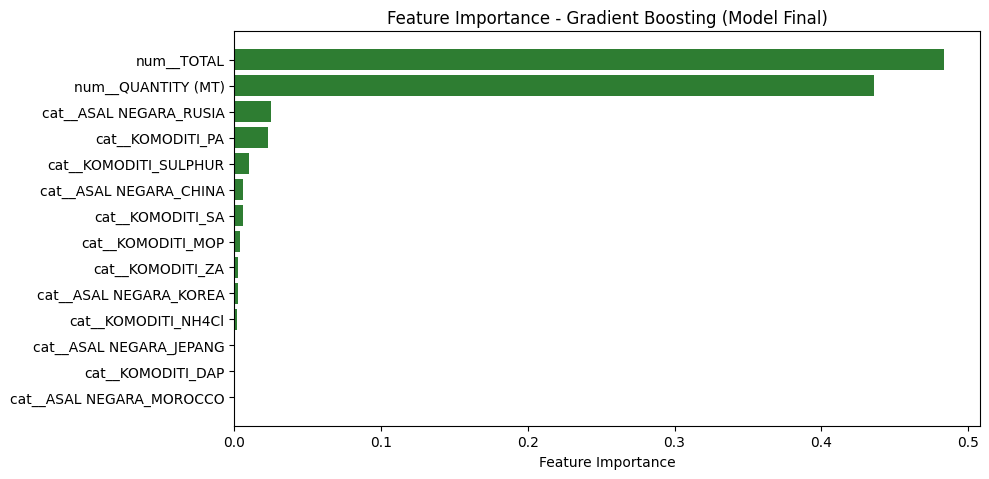

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, max(4, len(fi_df)*0.35)))
plt.barh(fi_df['Fitur'][::-1], fi_df['Bobot'][::-1], color='#2E7D32')
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Gradient Boosting (Model Final)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

## 9. Visualisasi Decision Tree (Model Pembanding)

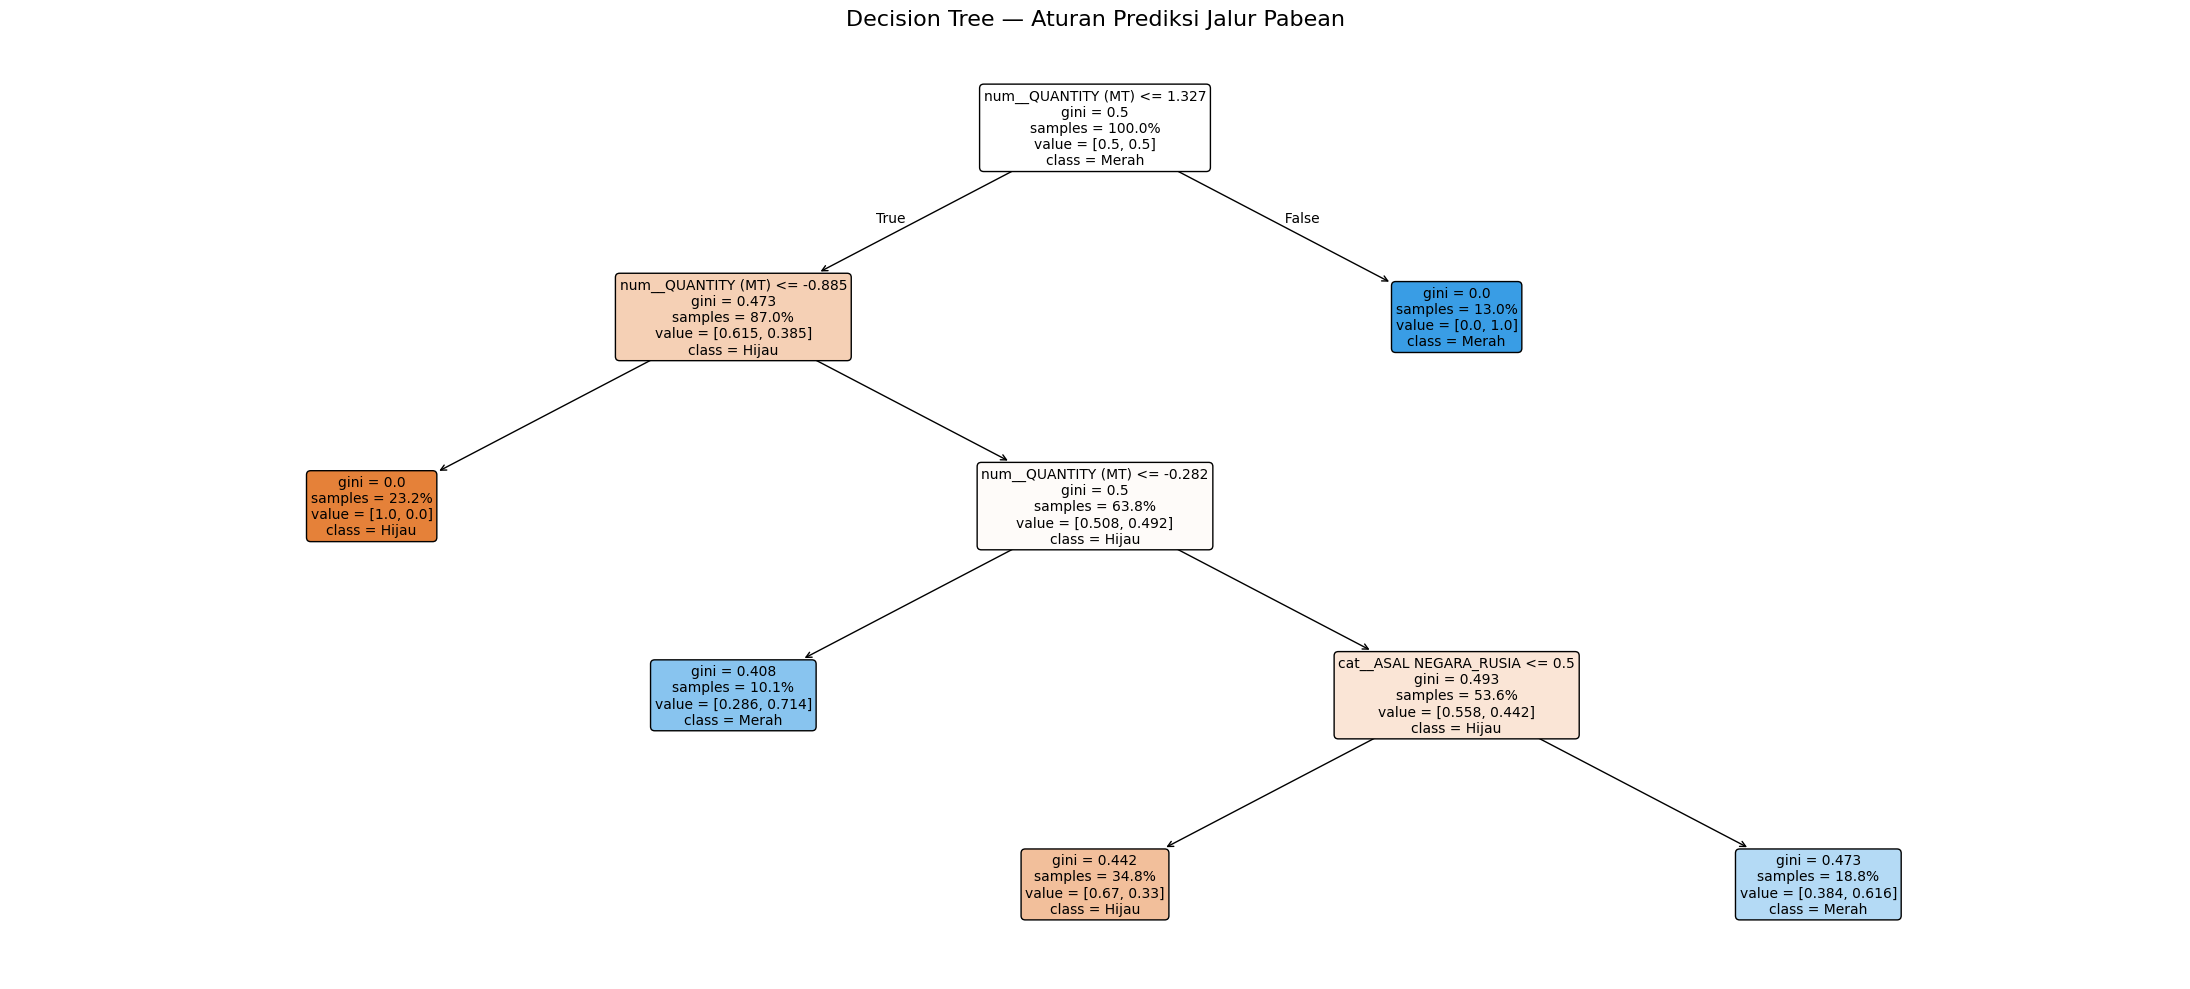

In [12]:
from sklearn.tree import plot_tree

dt_feature_names = dt_model.named_steps['prep'].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    dt_model.named_steps['clf'],
    feature_names=list(dt_feature_names),
    class_names=['Hijau', 'Merah'],
    filled=True, rounded=True, fontsize=10, proportion=True
)
plt.title("Decision Tree — Aturan Prediksi Jalur Pabean", fontsize=16)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=120)
plt.show()

## 10. Uji Prediksi dengan Data Baru

Contoh: memprediksi jalur untuk kapal baru menggunakan model final (Gradient Boosting).

In [13]:
def prediksi_jalur(komoditi, asal_negara, quantity_mt, total_pajak, model=final_model, label=""):
    data_baru = pd.DataFrame([{
        'KOMODITI': komoditi,
        'ASAL NEGARA': asal_negara,
        'QUANTITY (MT)': quantity_mt,
        'TOTAL': total_pajak,
    }])
    pred = model.predict(data_baru)[0]
    proba = model.predict_proba(data_baru)[0]

    hasil = "MERAH 🔴" if pred == 1 else "HIJAU 🟢"
    keyakinan = proba[1]*100 if pred == 1 else proba[0]*100
    print(f"[{label}] Prediksi: {hasil} (keyakinan {keyakinan:.1f}%)")
    return pred, proba

# Contoh sama seperti di notebook lama
prediksi_jalur('SULPHUR', 'RUSIA', 28000, 9_500_000_000, model=final_model, label="Gradient Boosting")
prediksi_jalur('SULPHUR', 'RUSIA', 28000, 9_500_000_000, model=dt_model, label="Decision Tree")

[Gradient Boosting] Prediksi: MERAH 🔴 (keyakinan 79.1%)
[Decision Tree] Prediksi: MERAH 🔴 (keyakinan 61.6%)


(np.int64(1), array([0.38356164, 0.61643836]))

## 11. Simpan Model

Kedua model disimpan: **Gradient Boosting** (`model_inklaring_gb.pkl`) sebagai model utama, dan **Decision Tree** (`model_inklaring_dt.pkl`) sebagai pembanding/model yang mudah dijelaskan. Preprocessing (One-Hot Encoding + Scaling) sudah tergabung di dalam `Pipeline`, jadi tidak perlu simpan daftar kolom encoding terpisah seperti versi lama — cukup panggil `.predict()` pada DataFrame mentah dengan kolom yang sama seperti `X`.

In [14]:
import joblib

joblib.dump(final_model, 'model_inklaring_gb.pkl')
joblib.dump(dt_model, 'model_inklaring_dt.pkl')

print("Model berhasil disimpan:")
print("- model_inklaring_gb.pkl (Gradient Boosting, model utama)")
print("- model_inklaring_dt.pkl (Decision Tree, model pembanding/mudah diinterpretasi)")
print()
print("Cara pakai ulang:")
print(">>> model = joblib.load('model_inklaring_gb.pkl')")
print(">>> model.predict(df_baru[['KOMODITI','ASAL NEGARA','QUANTITY (MT)','TOTAL']])")

Model berhasil disimpan:
- model_inklaring_gb.pkl (Gradient Boosting, model utama)
- model_inklaring_dt.pkl (Decision Tree, model pembanding/mudah diinterpretasi)

Cara pakai ulang:
>>> model = joblib.load('model_inklaring_gb.pkl')
>>> model.predict(df_baru[['KOMODITI','ASAL NEGARA','QUANTITY (MT)','TOTAL']])


## 12. Catatan & Rekomendasi untuk Ke Depannya

**Tentang performa model:**
- Dengan data ~69 baris, balanced accuracy terbaik yang dicapai ~0.65-0.70 (dari tebakan acak 0.50). Ini jauh lebih baik dari acak, tapi belum "sangat akurat" — realistis mengingat jumlah data dan bahwa kebijakan jalur bisa berubah tiap tahun (temuan Anda sendiri).
- Gradient Boosting sedikit lebih unggul dari Decision Tree, tapi selisihnya masih dalam rentang variasi random — jangan terlalu yakin satu model "pasti lebih baik" sampai data bertambah.

**Fitur yang penting:**
- `KOMODITI` dan `QUANTITY (MT)` adalah fitur dengan sinyal paling kuat dan konsisten.
- `ASAL NEGARA` dan `TOTAL` (pajak) dipertahankan karena relevan secara domain, meski secara statistik di data saat ini belum terlalu signifikan.
- Fitur dengan kategori terlalu beragam (`Port of Load`, `PEMASOK`, `PENGIRIM`) sebaiknya dihindari kecuali nanti di-grouping (misal per wilayah/negara pengirim) supaya jumlah kategori lebih sedikit.

**Untuk meningkatkan akurasi ke depan:**
1. **Kumpulkan data lintas tahun** (2024, 2025, 2026, dst) meski kebijakan berbeda — tambahkan kolom `Tahun` sebagai fitur, model bisa belajar pola per-periode kebijakan.
2. Saat data bertambah signifikan (>200-300 baris), model seperti Random Forest/XGBoost/Gradient Boosting akan punya ruang untuk benar-benar unggul dari Decision Tree.
3. Pertimbangkan menambahkan fitur historis, misalnya: berapa kali pemasok/PPJK yang sama kena Jalur Merah di masa lalu (bisa jadi sinyal kuat tapi butuh riwayat data lebih panjang).
4. Update model secara berkala (mis. tiap kuartal) karena kebijakan jalur bisa berubah — model lama bisa jadi kurang relevan untuk periode kebijakan baru.
